In [1]:
from PIL import Image, ImageDraw
import drawsvg as draw
import shapely.geometry as Geom
import numpy as np

In [2]:
def make_bezier(xys: list[tuple]):
    # xys should be a sequence of 2-tuples (Bezier control points)
    n = len(xys)
    combinations = pascal_row(n-1)
    def bezier(ts):
        # This uses the generalized formula for bezier curves
        # http://en.wikipedia.org/wiki/B%C3%A9zier_curve#Generalization
        result = []
        for t in ts:
            tpowers = (t**i for i in range(n))
            upowers = reversed([(1-t)**i for i in range(n)])
            coefs = [c*a*b for c, a, b in zip(combinations, tpowers, upowers)]
            result.append(
                tuple(sum([coef*p for coef, p in zip(coefs, ps)]) for ps in zip(*xys)))
        return result
    return bezier

def pascal_row(n, memo={}):
    # This returns the nth row of Pascal's Triangle
    if n in memo:
        return memo[n]
    result = [1]
    x, numerator = 1, n
    for denominator in range(1, n//2+1):
        # print(numerator,denominator,x)
        x *= numerator
        x /= denominator
        result.append(x)
        numerator -= 1
    if n&1 == 0:
        # n is even
        result.extend(reversed(result[:-1]))
    else:
        result.extend(reversed(result))
    memo[n] = result
    return result

In [62]:
def DrawStroke(canvas: Image, strokepath: list[tuple], thickness: float = 6.0):
    _active_canvas = canvas

    if not hasattr(_active_canvas, "margin"): raise AttributeError('canvas does not have attribute "margin"')
    if not hasattr(_active_canvas, "subdivision"): raise AttributeError('canvas does not have attribute "subdivision"')

    _canvas_area = tuple(x - canvas.margin * 2 for x in canvas.size)
    _canvas_fraction = tuple(x/canvas.subdivision for x in _canvas_area)

    # repeat coords to reduce bezier smoothing; _weighting = level of smoothness
    _weighting = 4
    _weighted_strokepath = []
    for coord in strokepath:
        _weighted_strokepath += [coord,] * _weighting

    _scaled_strokepath = []
    for i, x in enumerate(_weighted_strokepath):
        _scaled_strokepath.append(tuple((canvas.margin + (x[n] * _canvas_fraction[n]) - (_canvas_fraction[n]/2)) for n in [0,1]))

    _draw = ImageDraw.Draw(_active_canvas)

    #generate n points along the bezier curve
    n_points = max(max(canvas.size), 64)
    _bezier_points = make_bezier(_scaled_strokepath)([t/n_points for t in range(n_points + 1)])

    for i, centre in enumerate(_bezier_points):
        _cur_thickness = (thickness - 1) * (len(_bezier_points) - i)/(len(_bezier_points)) + 1

        _draw.ellipse((centre[0] - _cur_thickness,
                       centre[1] - _cur_thickness,
                       centre[0] + _cur_thickness,
                       centre[1] + _cur_thickness),
                       fill=(0,0,0,255))
    return _active_canvas

def DrawCharacter(strokes: list[list[tuple]],
                  thickness: float | list[float] = 6.0,
                  margin: int = 1,
                  subdivision: int = 7,
                  mode: str = "RGBA", size: tuple[int,int] = (128,128), color: tuple[int,int,int,int] = (255,255,255,255)):
    if type(thickness) is list:
        if len(thickness) > 1 and len(thickness) != len(strokes):
            raise ValueError('strokes and thickness must be the same length!')

    _active_canvas = Image.new(mode = mode,
                                size = size,
                                color = color)
    _active_canvas.margin = margin
    _active_canvas.subdivision = subdivision

    for idx, stroke in enumerate(strokes):
        if type(thickness) is list:
            _cur_thickness = thickness[idx]
        else:
            _cur_thickness = thickness
        _active_canvas = DrawStroke(_active_canvas, stroke, _cur_thickness)

    return _active_canvas

In [63]:
character_dict = {}

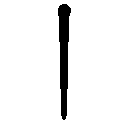

In [64]:
name = "1"
glyph = DrawCharacter([[(4,1),(4,7)]])
character_dict[name] = glyph

glyph

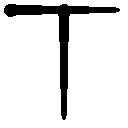

In [65]:
name = "2"
glyph = DrawCharacter([[(1,1),(7,1)],[(4,1),(4,7)]])
character_dict[name] = glyph

glyph

In [ ]:
name = "3"
glyph = DrawCharacter([[(1,1),(7,1)],[(1,3),(7,3)],[(4,1),(4,7)]])
character_dict[name] = glyph

glyph

{'1': <PIL.Image.Image image mode=RGBA size=128x128 at 0x1B76B463A70>, '2': <PIL.Image.Image image mode=RGBA size=128x128 at 0x1B76B463440>, '3': <PIL.Image.Image image mode=RGBA size=128x128 at 0x1B76B385070>}
